# 2 · Modeli

Pet pristupa, isti zadatak (gusta mapa dubine iz RGB), razlicita strategija ekstrakcije
reprezentacija i trosak treniranja. Ceo kod modela je u `src/cyclops/models/` - ovde ga
samo pozivamo i prikazujemo rezultate.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')            # run from the repo root so paths resolve
sys.path.insert(0, 'src')
sys.path.insert(0, 'scripts')

import json
import numpy as np
import matplotlib.pyplot as plt

meta = json.loads(Path('outputs/samples/meta.json').read_text())
order = ['01_resnet50', '02_sd_unet', '03_ijepa', '04_fusion', '05_depth_anything']
labels = dict([('01_resnet50', 'ResNet-50'), ('02_sd_unet', 'SD-UNet'), ('03_ijepa', 'I-JEPA'), ('04_fusion', 'Fusion'), ('05_depth_anything', 'DepthAnything')])

| # | Pristup | Enkoder | Sta se trenira |
|---|---------|---------|----------------|
| 1 | Nadgledani baseline | ResNet-50 | ceo model (enkoder + dekoder) |
| 2 | Frozen SD-UNet + dekoder | Stable Diffusion 1.5 UNet | samo dekoder |
| 3 | Frozen I-JEPA + dekoder | I-JEPA ViT-H/14 | samo DPT dekoder |
| 4 | Fuzija SD + I-JEPA | SD-1.5 + I-JEPA | fuzija + dekoder |
| 5 | DepthAnything V2 (eval-only) | ViT / DINOv2 | nista (zero-shot) |

Pristupi 2-5 koriste **zamrznute** enkodere - reprezentacije velikih predtreniranih modela,
nad kojima se uci samo lagani dekoder.

## Trenabilni parametri i vreme inferencije

model               trainable        total    ms/img
ResNet-50             30.16M      30.16M       6.5
SD-UNet                5.73M     948.91M      98.6
I-JEPA                 7.90M     638.67M     142.5
Fusion                11.26M    1585.20M     239.7
DepthAnything          0.00M      97.47M      60.5


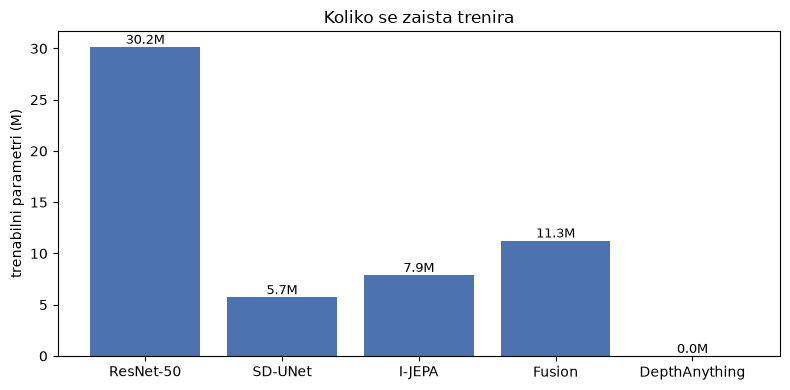

In [2]:
print(f"{'model':16s}{'trainable':>13s}{'total':>13s}{'ms/img':>10s}")
for k in order:
    m = meta[k]
    print(f"{labels[k]:16s}{m['trainable_params']/1e6:11.2f}M{m['total_params']/1e6:11.2f}M"
          f"{m['inference_ms']:10.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
vals = [meta[k]['trainable_params']/1e6 for k in order]
ax.bar([labels[k] for k in order], vals, color='#4c72b0')
ax.set_ylabel('trenabilni parametri (M)'); ax.set_title('Koliko se zaista trenira')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.1f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

Kljucna prednost frozen pristupa: iako je *ukupan* broj parametara ogroman (SD, ViT-H),
**trenira se samo mali dekoder** - jeftino i brzo, bez rizika od prenaucavanja enkodera.

## Kvalitativno poredjenje

Predikcije svih pet modela na istim test slikama (ista skala boja po redu). DepthAnything
je median-poravnat na GT (zero-shot protokol).

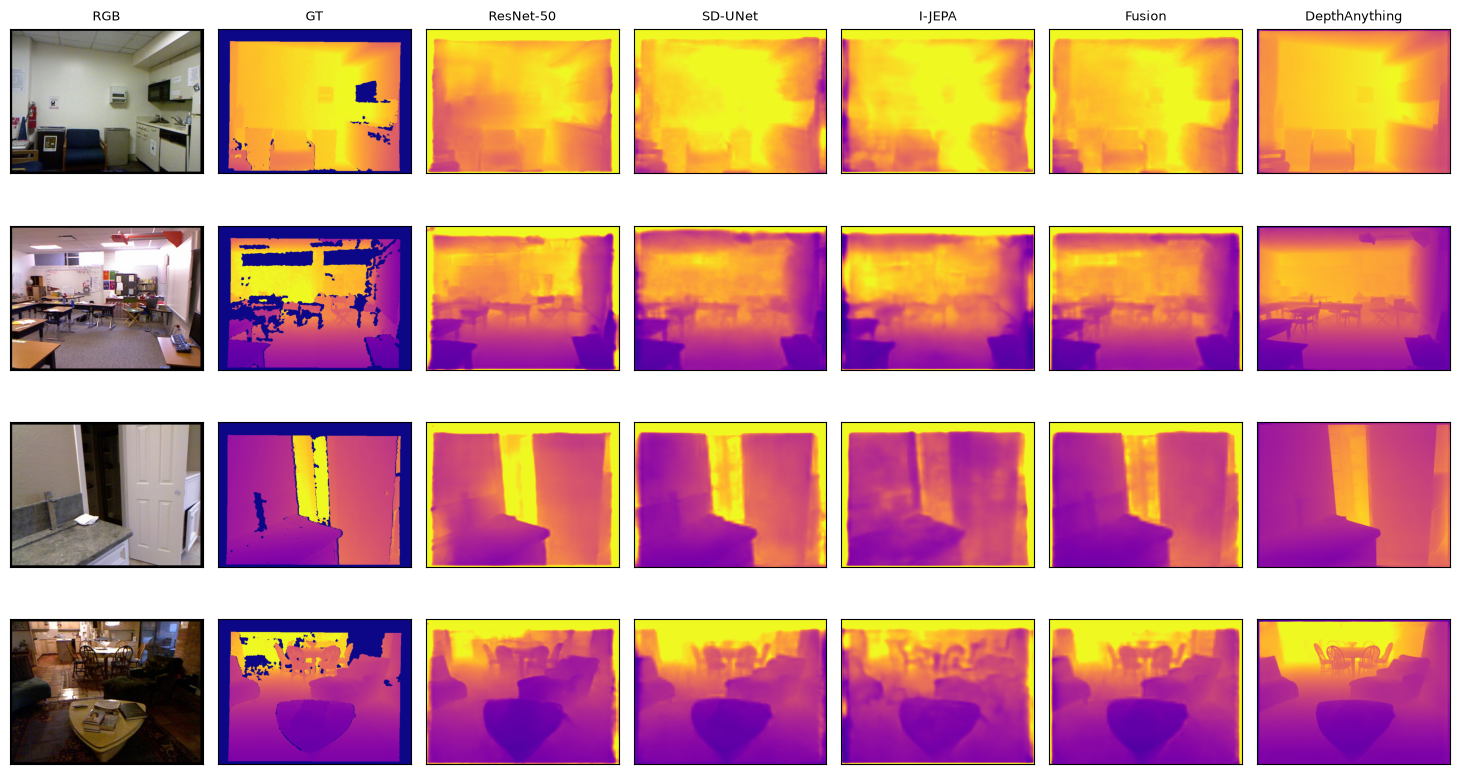

In [3]:
samples = sorted(Path('outputs/samples').glob('sample_*.npz'))
cols = ['RGB', 'GT'] + [labels[o] for o in order]
fig, axes = plt.subplots(len(samples), len(cols), figsize=(2.1*len(cols), 2.1*len(samples)))
for r, sp in enumerate(samples):
    d = np.load(sp)
    vmax = float(np.percentile(d['gt'][d['mask'].astype(bool)], 95))
    axes[r, 0].imshow(d['rgb'])
    axes[r, 1].imshow(d['gt'], cmap='plasma', vmin=0, vmax=vmax)
    for c, o in enumerate(order):
        axes[r, c+2].imshow(d[f'pred_{o}'], cmap='plasma', vmin=0, vmax=vmax)
    for c in range(len(cols)):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(cols[c], fontsize=9)
plt.tight_layout(); plt.show()

**Zakljucak.** SD-UNet, Fuzija i DepthAnything daju najostrije, geometrijski najverovatnije
mape; ResNet-50 baseline je najgrublji. Vizuelni utisak prati kvantitativne metrike (notebook 3).